## 1.1 Importación de Librerías y Carga de Datos

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Nicossm/parcial1/main/data/raw/software_developer_salary_raw.csv')

# 1. Análisis Exploratorio Inicial (EDA)

In [4]:
# Vista inicial de los datos
df.head()

,experience,country,education,languages,frameworks,company_size,salary_usd
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189
1,38,France,Masters,"Ruby, Python",NaN,201-1000,147754
2,36,USA,Some College,"PHP, C++","Spring, Ruby on Rails",5000+,220819
3,3,India,masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943
4,18,USA,Masters,"Go, Java","React, Django",5000+,166442


In [5]:
# Informacion general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   experience    9676 non-null   object
 1   country       10300 non-null  object
 2   education     9474 non-null   object
 3   languages     9467 non-null   object
 4   frameworks    9477 non-null   object
 5   company_size  10300 non-null  object
 6   salary_usd    9670 non-null   object
dtypes: object(7)
memory usage: 563.4+ KB


In [6]:
# Count: valores no nulos
# unique: cant valores unicos
# top: moda
# freq: cant del valor en top
display(df.describe())

,experience,country,education,languages,frameworks,company_size,salary_usd
count,9676,10300,9474,9467,9477,10300,9670
unique,79,55,30,100,100,6,9091
top,32,USA,Bachelors,"Rust, Ruby","Angular, Express",11-50,missing
freq,270,3910,4572,123,118,1786,25


## 1.3 Detección de Valores Nulos (NaN)

In [7]:
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna)

experience      624
country           0
education       826
languages       833
frameworks      823
company_size      0
salary_usd      630
dtype: int64


In [8]:
# Porcentaje de nulos para decidir si imputar o eliminar
print("\n--- Porcentaje de Valores Nulos ---")
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0].round(2).astype(str) + '%')


--- Porcentaje de Valores Nulos ---
experience    6.06%
education     8.02%
languages     8.09%
frameworks    7.99%
salary_usd    6.12%
dtype: object


## 1.4 Detección de Duplicados

In [9]:
total_duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {total_duplicados}")

Total de filas duplicadas: 211


In [10]:
if total_duplicados > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(4))

,experience,country,education,languages,frameworks,company_size,salary_usd
879,0,Canada,Masters,"PHP, Java","React, Express",1001-5000,61172
5799,0,Canada,Masters,"PHP, Java","React, Express",1001-5000,61172
1891,0,Canada,Some College,"C#, Rust","Spring, ASP.NET",1-10,61344
9792,0,Canada,Some College,"C#, Rust","Spring, ASP.NET",1-10,61344


## 1.5 Detección de Outliers


In [11]:
def detectar_outliers_iqr(df, columna):
    # Forzar numérico por si hay tipos mezclados
    temp_series = pd.to_numeric(df[columna], errors='coerce')

    Q1 = temp_series.quantile(0.25)
    Q3 = temp_series.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = temp_series[(temp_series < limite_inferior) | (temp_series > limite_superior)]

    print(f"--- Análisis Outliers: {columna} ---")
    print(f"Límite Inferior: {limite_inferior:.2f}")
    print(f"Límite Superior: {limite_superior:.2f}")
    print(f"Cantidad de Outliers detectados: {len(outliers)}\n")

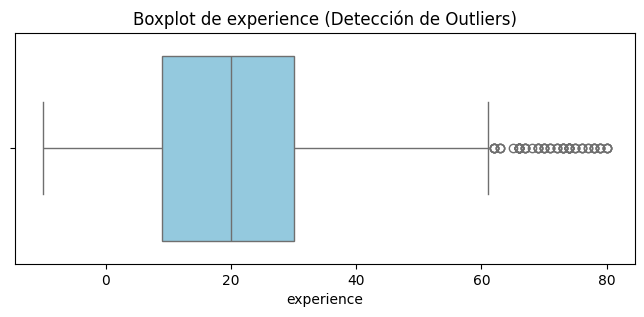

--- Análisis Outliers: experience ---
Límite Inferior: -22.50
Límite Superior: 61.50
Cantidad de Outliers detectados: 73



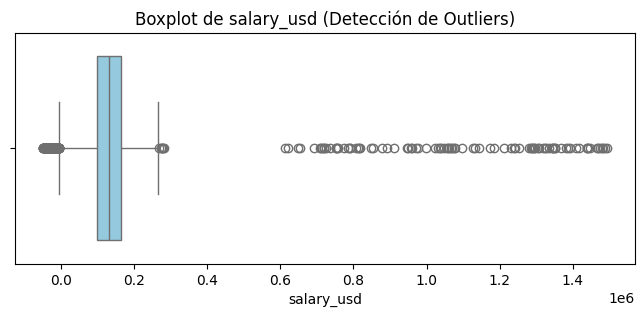

--- Análisis Outliers: salary_usd ---
Límite Inferior: -5204.25
Límite Superior: 266737.75
Cantidad de Outliers detectados: 184



In [12]:
columnas_numericas = ['experience', 'salary_usd']
for col in columnas_numericas:
    # Boxplot
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=pd.to_numeric(df[col], errors='coerce'), color='skyblue')
    plt.title(f'Boxplot de {col} (Detección de Outliers)')
    plt.show()

    # Cálculos IQR
    detectar_outliers_iqr(df, col)

## 1.6 Visualizaciones Iniciales (Distribuciones y Relaciones)

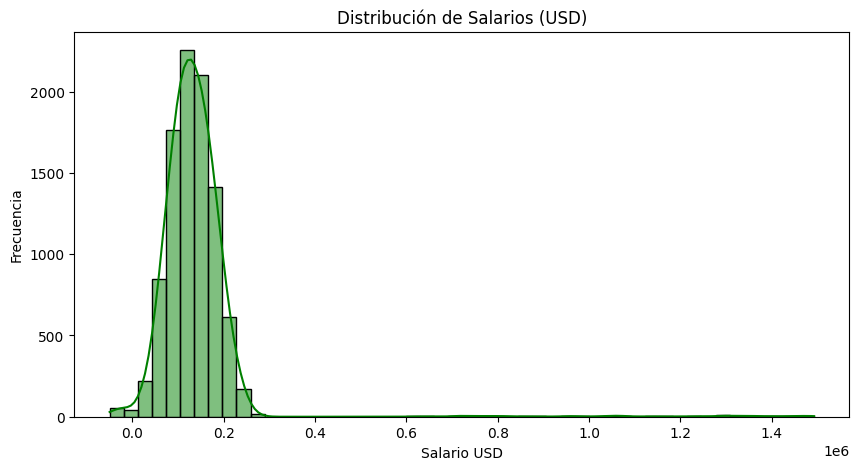

In [13]:
# 1. Distribución de la variable salary_usd
plt.figure(figsize=(10, 5))
sns.histplot(pd.to_numeric(df['salary_usd'], errors='coerce'), bins=50, kde=True, color='green')
plt.title('Distribución de Salarios (USD)')
plt.xlabel('Salario USD')
plt.ylabel('Frecuencia')
plt.show()


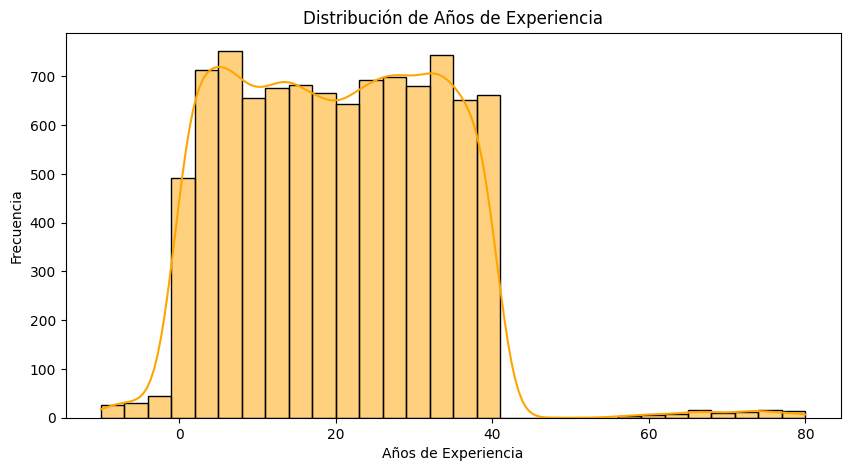

In [14]:
# 2. Distribución de la Experiencia
plt.figure(figsize=(10, 5))
sns.histplot(pd.to_numeric(df['experience'], errors='coerce'), bins=30, kde=True, color='orange')
plt.title('Distribución de Años de Experiencia')
plt.xlabel('Años de Experiencia')
plt.ylabel('Frecuencia')
plt.show()

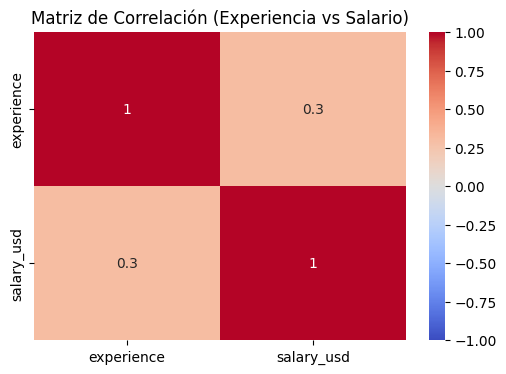

In [15]:
# 3. Correlación entre variables salario y experiencia
plt.figure(figsize=(6, 4))
df_num = pd.DataFrame()
for col in columnas_numericas:
    df_num[col] = pd.to_numeric(df[col], errors='coerce')
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Experiencia vs Salario)')
plt.show()

# 2. Limpieza de Datos

## 2.2 Copia de trabajo para no modificar el DataFrame original

In [16]:
df_clean = df.copy()
print("Shape original:", df.shape)
print("Shape copia de trabajo:", df_clean.shape)

Shape original: (10300, 7)
Shape copia de trabajo: (10300, 7)


## 2.3 Funciones auxiliares de limpieza

### 2.3.1 Función para normalizar listas separadas por coma

In [17]:
def normalizar_lista_tecnologias(valor):
    if pd.isna(valor):
        return np.nan

    tokens = [x.strip() for x in str(valor).split(",") if x.strip() != ""]

    if len(tokens) == 0:
        return np.nan

    # Eliminar repetidos internos y ordenar para estandarizar
    tokens_unicos = sorted(set(tokens), key=str.lower)

    return ", ".join(tokens_unicos)

### 2.3.2 Función para normalizar países

In [18]:
def normalizar_country(valor):
    if pd.isna(valor):
        return np.nan

    v = str(valor).strip().upper().replace('.', '')

    mapa_paises = {
        # USA
        "USA": "USA",
        "US": "USA",
        "UNITED STATES": "USA",
        "UNITED STATES OF AMERICA": "USA",
        "USA": "USA",

        # UK
        "UK": "UK",
        "GB": "UK",
        "GREAT BRITAIN": "UK",
        "UNITED KINGDOM": "UK",

        # Germany
        "GERMANY": "Germany",
        "DE": "Germany",
        "DEUTSCHLAND": "Germany",

        # Otros
        "FRANCE": "France",
        "FR": "France",

        "JAPAN": "Japan",
        "JP": "Japan",

        "INDIA": "India",
        "IN": "India",

        "BRAZIL": "Brazil",
        "BR": "Brazil",

        "CANADA": "Canada",
        "CA": "Canada",

        "AUSTRALIA": "Australia",
        "AU": "Australia",

        "SINGAPORE": "Singapore",
        "SG": "Singapore"
    }

    return mapa_paises.get(v, str(valor).strip().title())

### 2.3.3 Función para normalizar educación

In [19]:
def normalizar_education(valor):
    if pd.isna(valor):
        return np.nan

    v = str(valor).strip().upper().replace('.', '').replace("'", "")

    mapa_education = {
        "HIGH SCHOOL": "High School",
        "HIGHSCHOOL": "High School",
        "SECONDARY": "High School",

        "SOME COLLEGE": "Some College",
        "SOMECOLLEGE": "Some College",
        "INCOMPLETE": "Some College",

        "BACHELORS": "Bachelors",
        "BACHELOR": "Bachelors",

        "MASTERS": "Masters",
        "MASTER": "Masters",

        "PHD": "PhD",
        "DOCTORATE": "PhD"
    }

    return mapa_education.get(v, str(valor).strip().title())

### 2.3.4 Función para resumir outliers con IQR

In [20]:
def resumen_outliers_iqr(df, columna):
    serie = pd.to_numeric(df[columna], errors="coerce").dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = (serie < limite_inferior) | (serie > limite_superior)
    cantidad_outliers = mascara_outliers.sum()

    return {
        "columna": columna,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": int(cantidad_outliers)
    }

### 2.3.5 Función para aplicar capping con IQR

In [21]:
def cap_outliers_iqr(serie):
    serie = pd.to_numeric(serie, errors="coerce")

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    serie_cap = serie.clip(lower=limite_inferior, upper=limite_superior)

    return serie_cap, limite_inferior, limite_superior

## 2.4 Unificación de nulos y pseudonulos

Antes de imputar o eliminar datos, primero hay que convertir todos los valores que significan “faltante” a un único formato (`NaN`).

Entre ellos se observaron casos como:

- `missing`
- `null`
- `NaN`
- `N/A`
- `n/a`
- `unknown`
- `?`
- celdas vacías

In [22]:
nulos_antes = df_clean.isnull().sum()

# Lista de pseudonulos a unificar
pseudonulos = [
    "missing", "Missing",
    "null", "NULL",
    "NaN", "nan",
    "N/A", "n/a",
    "NA", "na",
    "unknown", "Unknown",
    "?", "-", ""
]

df_clean = df_clean.replace(pseudonulos, np.nan)

In [23]:
# Conteo posterior
nulos_despues_unificacion = df_clean.isnull().sum()

comparacion_nulos = pd.DataFrame({
    "nulos_antes": nulos_antes,
    "nulos_despues_unificacion": nulos_despues_unificacion,
    "incremento": nulos_despues_unificacion - nulos_antes
})

print("Comparación de nulos antes y después de unificar pseudonulos:")
display(comparacion_nulos)

Comparación de nulos antes y después de unificar pseudonulos:


,nulos_antes,nulos_despues_unificacion,incremento
experience,624,709,85
country,0,0,0
education,826,826,0
languages,833,833,0
frameworks,823,823,0
company_size,0,0,0
salary_usd,630,713,83


## 2.5 Normalización de variables categóricas

### 2.5.1 Normalizar `country` y `education`

In [24]:
df_clean["country"] = df_clean["country"].apply(normalizar_country)
df_clean["education"] = df_clean["education"].apply(normalizar_education)

print("Valores únicos de country después de normalizar:")
print(sorted(df_clean["country"].dropna().unique())[:20])

print("\nValores únicos de education después de normalizar:")
print(sorted(df_clean["education"].dropna().unique()))

Valores únicos de country después de normalizar:
['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Japan', 'Singapore', 'UK', 'USA']

Valores únicos de education después de normalizar:
['Bachelors', 'High School', 'Masters', 'PhD', 'Some College']


### 2.5.2 Normalizar `languages` y `frameworks`

In [25]:
df_clean["languages"] = df_clean["languages"].apply(normalizar_lista_tecnologias)
df_clean["frameworks"] = df_clean["frameworks"].apply(normalizar_lista_tecnologias)

print("Ejemplo de values_counts en languages:")
display(df_clean["languages"].value_counts(dropna=False).head(10))

print("\nEjemplo de values_counts en frameworks:")
display(df_clean["frameworks"].value_counts(dropna=False).head(10))

Ejemplo de values_counts en languages:


,count
languages,
NaN,833
"C++, Ruby",214
"Go, Swift",207
"Ruby, Rust",207
"C#, C++",204
"PHP, Python",202
"JavaScript, Ruby",200
"JavaScript, PHP",199
"C++, Swift",198



Ejemplo de values_counts en frameworks:


,count
frameworks,
NaN,823
"Django, Spring",229
"ASP.NET, Spring",224
"Angular, Express",212
"Laravel, Ruby on Rails",211
"Ruby on Rails, Spring",207
"Django, Laravel",202
"Angular, Laravel",201
"Django, React",200


### 2.5.3 Limpieza de `company_size`

In [26]:
df_clean["company_size"] = df_clean["company_size"].astype(str).str.strip()
df_clean["company_size"] = df_clean["company_size"].replace("nan", np.nan)

print("Valores únicos de company_size:")
print(sorted(df_clean["company_size"].dropna().unique()))

Valores únicos de company_size:
['1-10', '1001-5000', '11-50', '201-1000', '5000+', '51-200']


## 2.6 Conversión de tipos de datos

In [27]:
#Las columnas `experience` y `salary_usd` deben ser numéricas para poder analizar nulos, outliers y estadísticas de manera correcta.
df_clean["experience"] = pd.to_numeric(df_clean["experience"], errors="coerce")
df_clean["salary_usd"] = pd.to_numeric(df_clean["salary_usd"], errors="coerce")

print("Tipos de datos después de convertir experience y salary_usd:")
print(df_clean.dtypes)

Tipos de datos después de convertir experience y salary_usd:
experience      float64
country          object
education        object
languages        object
frameworks       object
company_size     object
salary_usd      float64
dtype: object


## 2.7 Tratamiento de valores imposibles en variables numéricas


### Reglas aplicadas

- `experience < 0`  → inválido
- `experience > 50` → inválido
- `salary_usd <= 0` → inválido

In [28]:
exp_invalidas = ((df_clean["experience"] < 0) | (df_clean["experience"] > 50)).sum()
salary_invalidos = (df_clean["salary_usd"] <= 0).sum()

print("Cantidad de experiencias inválidas detectadas:", int(exp_invalidas))
print("Cantidad de salarios inválidos detectados:", int(salary_invalidos))

# Reemplazo por NaN
df_clean.loc[(df_clean["experience"] < 0) | (df_clean["experience"] > 50), "experience"] = np.nan
df_clean.loc[df_clean["salary_usd"] <= 0, "salary_usd"] = np.nan

print("\nNulos después de invalidar valores imposibles:")
print(df_clean[["experience", "salary_usd"]].isnull().sum())

Cantidad de experiencias inválidas detectadas: 195
Cantidad de salarios inválidos detectados: 97

Nulos después de invalidar valores imposibles:
experience    904
salary_usd    810
dtype: int64


## 2.8 Eliminación de duplicados

In [29]:
duplicados_antes = df_clean.duplicated().sum()
print("Duplicados detectados antes de eliminar:", duplicados_antes)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

duplicados_despues = df_clean.duplicated().sum()
print("Duplicados después de eliminar:", duplicados_despues)
print("Nuevo shape:", df_clean.shape)

Duplicados detectados antes de eliminar: 256
Duplicados después de eliminar: 0
Nuevo shape: (10044, 7)


## 2.9 Manejo de valores nulos

### Decisiones adoptadas

- `salary_usd`: eliminar filas con nulo porque es la variable principal del análisis
- `experience`: imputar con mediana
- `country`, `education`, `languages`, `frameworks`, `company_size`: completar con `Unknown`

In [30]:
print("Nulos antes del tratamiento final:")
display(df_clean.isnull().sum())

Nulos antes del tratamiento final:


,0
experience,885
country,0
education,804
languages,807
frameworks,800
company_size,0
salary_usd,795


### 2.9.1 Eliminar filas sin salario

In [31]:
filas_antes = df_clean.shape[0]

df_clean = df_clean.dropna(subset=["salary_usd"]).copy()

filas_despues = df_clean.shape[0]
filas_eliminadas = filas_antes - filas_despues

print("Filas eliminadas por salary_usd nulo:", filas_eliminadas)
print("Shape después de eliminar salary_usd nulo:", df_clean.shape)

Filas eliminadas por salary_usd nulo: 795
Shape después de eliminar salary_usd nulo: (9249, 7)


### 2.9.2 Imputar `experience` con mediana

In [32]:
mediana_experience = df_clean["experience"].median()
print("Mediana de experience:", mediana_experience)

df_clean["experience"] = df_clean["experience"].fillna(mediana_experience)
df_clean["experience"] = df_clean["experience"].round().astype("Int64")

print("Nulos en experience después de imputar:", df_clean["experience"].isnull().sum())
print("Tipo final de experience:", df_clean["experience"].dtype)

Mediana de experience: 20.0
Nulos en experience después de imputar: 0
Tipo final de experience: Int64


### 2.9.3 Imputar categóricas con `Unknown`


In [33]:
columnas_categoricas = ["country", "education", "languages", "frameworks", "company_size"]

for col in columnas_categoricas:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("Nulos después de completar categóricas:")
display(df_clean[columnas_categoricas].isnull().sum())

Nulos después de completar categóricas:


,0
country,0
education,0
languages,0
frameworks,0
company_size,0


### Feature Engineering en variables multivaluadas

Las variables "languages" y "frameworks" contienen múltiples valores por registro.

En lugar de aplicar una transformación multietiqueta, se optó por generar nuevas variables que representan la cantidad de elementos en cada caso. Esto permite capturar información relevante sin aumentar significativamente la dimensionalidad del dataset.

In [34]:
df_clean['num_languages'] = df_clean['languages'].apply(lambda x: len([i.strip() for i in str(x).split(',')]))
df_clean['num_frameworks'] = df_clean['frameworks'].apply(lambda x: len([i.strip() for i in str(x).split(',')]))

## 2.10 Tratamiento de outliers

### 2.10.1 Revisar outliers de salario antes del capping

In [35]:
#Se aplicará la técnica de **capping con IQR** para `salary_usd`

resumen_salary_antes = resumen_outliers_iqr(df_clean, "salary_usd")

print("Resumen de outliers en salary_usd antes del capping:")
for k, v in resumen_salary_antes.items():
    print(f"{k}: {v}")

Resumen de outliers en salary_usd antes del capping:
columna: salary_usd
q1: 98034.0
q3: 165286.0
iqr: 67252.0
limite_inferior: -2844.0
limite_superior: 266164.0
cantidad_outliers: 99


### 2.10.2 Aplicar capping a `salary_usd`

In [36]:
# copia para comparación
df_clean["salary_usd_before_cap"] = df_clean["salary_usd"].copy()

# Aplicar capping
df_clean["salary_usd"], lim_inf_salary, lim_sup_salary = cap_outliers_iqr(df_clean["salary_usd"])

print("Límite inferior aplicado:", lim_inf_salary)
print("Límite superior aplicado:", lim_sup_salary)

Límite inferior aplicado: -2844.0
Límite superior aplicado: 266164.0


### 2.10.3 Verificar outliers de salario después del capping

In [37]:
resumen_salary_despues = resumen_outliers_iqr(df_clean, "salary_usd")

print("Resumen de outliers en salary_usd después del capping:")
for k, v in resumen_salary_despues.items():
    print(f"{k}: {v}")

Resumen de outliers en salary_usd después del capping:
columna: salary_usd
q1: 98034.0
q3: 165286.0
iqr: 67252.0
limite_inferior: -2844.0
limite_superior: 266164.0
cantidad_outliers: 0


## 2.11 Validación antes vs después

In [38]:
#se comparará el estado del dataset original contra el dataset limpio.
resumen_comparativo = pd.DataFrame({
    "dataset": ["Original", "Limpio"],
    "filas": [df.shape[0], df_clean.shape[0]],
    "columnas": [df.shape[1], df_clean.shape[1]],
    "duplicados": [df.duplicated().sum(), df_clean.duplicated().sum()],
    "nulos_experience": [df["experience"].isnull().sum(), df_clean["experience"].isnull().sum()],
    "nulos_salary_usd": [df["salary_usd"].isnull().sum(), df_clean["salary_usd"].isnull().sum()]
})

display(resumen_comparativo)

,dataset,filas,columnas,duplicados,nulos_experience,nulos_salary_usd
0,Original,10300,7,211,624,630
1,Limpio,9249,10,1,0,0


## 2.12 Revisión final de nulos y tipos

In [39]:
print("Nulos finales por columna:")
display(df_clean.isnull().sum())

Nulos finales por columna:


,0
experience,0
country,0
education,0
languages,0
frameworks,0
company_size,0
salary_usd,0
num_languages,0
num_frameworks,0
salary_usd_before_cap,0


In [40]:
print("\nTipos de datos finales:")
print(df_clean.dtypes)


Tipos de datos finales:
experience                 Int64
country                   object
education                 object
languages                 object
frameworks                object
company_size              object
salary_usd               float64
num_languages              int64
num_frameworks             int64
salary_usd_before_cap    float64
dtype: object


In [41]:
print("\nVista previa del dataset limpio:")
display(df_clean.head())


Vista previa del dataset limpio:


,experience,country,education,languages,frameworks,company_size,salary_usd,num_languages,num_frameworks,salary_usd_before_cap
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,2,2,122189.0
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,2,1,147754.0
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,2,2,220819.0
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,2,2,31943.0
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,2,2,166442.0


## 2.13 Visualización antes y después del tratamiento de outliers

### 2.13.1 Boxplot de salario antes y después

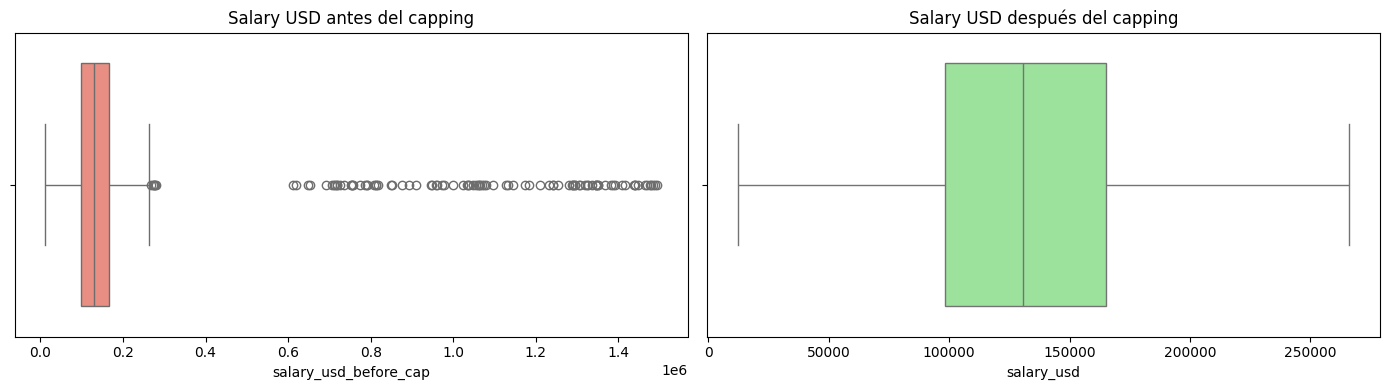

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df_clean["salary_usd_before_cap"], ax=axes[0], color="salmon")
axes[0].set_title("Salary USD antes del capping")

sns.boxplot(x=df_clean["salary_usd"], ax=axes[1], color="lightgreen")
axes[1].set_title("Salary USD después del capping")

plt.tight_layout()
plt.show()

In [43]:
display(df_clean)

,experience,country,education,languages,frameworks,company_size,salary_usd,num_languages,num_frameworks,salary_usd_before_cap
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,2,2,122189.0
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,2,1,147754.0
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,2,2,220819.0
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,2,2,31943.0
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,2,2,166442.0
...,...,...,...,...,...,...,...,...,...,...
10039,20,France,Bachelors,"Go, Rust","Angular, Express",1-10,154727.0,2,2,154727.0
10040,5,Japan,Masters,Unknown,"Laravel, Vue",1001-5000,69876.0,1,2,69876.0
10041,21,USA,Unknown,"Python, Swift","Django, Express",11-50,154794.0,2,2,154794.0
10042,37,USA,Masters,"C#, Swift","Angular, Laravel",51-200,178945.0,2,2,178945.0
